<table style="width:100%">
<tr>
<td style="vertical-align:middle; text-align:left;">
<font size="2">
Supplementary code for the <a href="http://mng.bz/orYv">Build a Large Language Model From Scratch</a> book by <a href="https://sebastianraschka.com">Sebastian Raschka</a><br>
<br>Code repository: <a href="https://github.com/rasbt/LLMs-from-scratch">https://github.com/rasbt/LLMs-from-scratch</a>
</font>
</td>
<td style="vertical-align:middle; text-align:left;">
<a href="http://mng.bz/orYv"><img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/cover-small.webp" width="100px"></a>
</td>
</tr>
</table>

In [35]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [36]:
import sys

# Ensure the execution path points directly to default .pixi environment
print(f"Active Interpreter Path: {sys.executable}")

Active Interpreter Path: /home/payman/projects/learning/ai-ml-master/build-a-llm-from-scratch-book/llms-from-scratch/.pixi/envs/default/bin/python


In [37]:
from importlib.metadata import version

pkgs = ["matplotlib", 
        "numpy", 
        "tiktoken", 
        "torch",
        "tensorflow" # For OpenAI's pretrained weights
       ]
for p in pkgs:
    print(f"{p} version: {version(p)}")

matplotlib version: 3.11.0
numpy version: 2.4.6
tiktoken version: 0.13.0
torch version: 2.12.1
tensorflow version: 2.21.0


# **Chapter 5: Pretraining on Unlabeled Data**

---

## **Table of Contents**

---

## **Introduction**

This chapter transitions the project from architectural assembly to functional training. The introduction outlines several core objectives essential for developing a capable model:

* **Pretraining and Training Loops**: Implementation of a training function to optimize the LLM's weights using unlabeled data.
* **Performance Evaluation**: Development of basic evaluation techniques to numerically assess the quality and "coherence" of the generated text during and after training.
* **Weight Management**: Instructions for saving and loading model weights, ensuring training can be resumed or models can be shared.
* **Foundation for Fine-Tuning**: Integration of openly available pretrained weights from OpenAI, which provides a high-performance starting point for specific downstream tasks like classification or instruction following.

Ultimately, this section prepares the model to move beyond generating random "gibberish" and start producing coherent, human-like text.

<figure style="text-align: center; width: 750px; margin: 0 auto;">
    <img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/01.webp" width=100%>
    <figcaption style="text-align: left; margin-top: 8px;">
        <strong>Figure 5.1</strong> The three main stages of coding an LLM. This chapter focuses on stage 2: pretraining the LLM (step4), which includes implementing the training code (step 5), evaluating the performance (step 6), and saving and loading model weights (step 7).
    </figcaption>
</figure>

The topics covered in this chapter are shown below:

<figure style="text-align: center; width: 750px; margin: 0 auto;">
    <img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/02.webp" width=200%>
    <figcaption style="text-align: left; margin-top: 8px;">
        <strong>Figure 5.2</strong> An overview of the topics covered in this chapter. We begin by recapping text generation (step 1) before moving on to discuss basic model evaluation techniques (step 2) and training and validation losses (step 3).
    </figcaption>
</figure>

---

## **5.1 Evaluating generative text models**

We start this section with a brief recap of initializing a GPT model using the code from the previous chapter. Then, we discuss basic evaluation metrics for LLMs. Lastly, we apply these evaluation metrics to a training and validation dataset.

### **5.1.1 Using GPT to generate text**

This sub-section focuses on setting up the previously coded LLM architecture from chapter 4 for the pretraining phase.

The key technical and functional points include:

* **Model Initialization**: The section recaps the initialization of the `GPTModel` using the namesake configuration for the 124-million-parameter GPT-2. 
* **Computational Efficiency**: A critical adjustment is made by shortening the context length from 1,024 to 256 tokens. This reduction significantly lowers the computational power required, making it possible to train the model on a standard laptop.
* **Utility Functions**: The source introduces two new utility functions, `text_to_token_ids` and `token_ids_to_text`, to streamline the conversion between human-readable strings and the integer tensors required by the model.
* **The Generation Pipeline**: It outlines the three-step flow: tokenizing input text, generating logit vectors through the model, and decoding the resulting token IDs back into human-readable text.
* **Initial Baseline**: Testing the model at this stage, before training has occurred, results in incoherent output (gibberish), highlighting the need for the numerical evaluation and training loops detailed in the subsequent sections.

Ultimately, this section provides the functional bridge between the model architecture and the training process by establishing a standard workflow for generating and observing text.

We initialize a GPT model using the code from the previous chapter:

In [38]:
import torch
from llms_from_scratch.ch05.main_chapter_code.previous_chapters import GPTModel


GPT_CONFIG_124M = {
    "vocab_size": 50257,   # Vocabulary size
    "context_length": 256, # Shortened context length (orig: 1024)
    "emb_dim": 768,        # Embedding dimension
    "n_heads": 12,         # Number of attention heads
    "n_layers": 12,        # Number of layers
    "drop_rate": 0.1,      # Dropout rate
    "qkv_bias": False      # Query-key-value bias
}

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval();  # Disable dropout during inference

- We use dropout of 0.1 above, but it's relatively common to train LLMs without dropout nowadays.
- Modern LLMs also don't use bias vectors in the `nn.Linear` layers for the query, key, and value matrices (unlike earlier GPT models), which is achieved by setting `"qkv_bias": False`.
- We reduce the context length (`context_length`) of only 256 tokens to reduce the computational resource requirements for training the model, whereas the original 124 million parameter GPT-2 model used 1024 tokens
  - This is so that more readers will be able to follow and execute the code examples on their laptop computer.
  - However, please feel free to increase the `context_length` to 1024 tokens (this would not require any code changes).
  - We will also load a model with a 1024 `context_length` later from pretrained weights.

Next, we use the `generate_text_simple` function from the previous chapter to generate text. In addition, we define two convenience functions, `text_to_token_ids` and `token_ids_to_text`, for converting between token and text representations that we use throughout this chapter.

<figure style="text-align: center; width: 750px; margin: 0 auto;">
    <img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/03.webp" width=100%>
    <figcaption style="text-align: left; margin-top: 8px;">
        <strong>Figure 5.3</strong> Generating text involves encoding text into token IDs that the LLM processes into logit vectors. The logit vectors are then converted back into token IDs, detokenized into a text representation.
    </figcaption>
</figure>

In [39]:
import tiktoken
from llms_from_scratch.ch05.main_chapter_code.previous_chapters import generate_text_simple


def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0) # add batch dimension
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0) # remove batch dimension
    return tokenizer.decode(flat.tolist())

start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you rentingetic wasnم refres RexMeCHicular stren


- As we can see above, the model does not produce good text because it has not been trained yet
- How do we measure or capture what "good text" is, in a numeric form, to track it during training?
- The next subsection introduces metrics to calculate a loss metric for the generated outputs that we can use to measure the training progress
- The next chapters on finetuning LLMs will also introduce additional ways to measure model quality

---

### **5.1.2 Calculating the text generation loss: cross-entropy and perplexity**

This section focuses on implementing numerical methods to assess the quality of text generated by an LLM during the training process and walks through the mathematical and programmatic steps required to evaluate how "far" a model's predictions are from the actual target text:

* **The Next-Token Framework**: Using a shifted target strategy (where targets are inputs moved one position forward), the model is tasked with predicting the next token in a sequence.
* **Probability Calculation**: Input tokens are fed into the model to produce logits, which are then transformed into probability scores via the softmax function.
* **Training Objective**: The goal of training is to maximize the likelihood of the correct token by increasing its probability relative to all other tokens in the vocabulary.
* **Cross Entropy Loss**: To optimize this, the model calculates the negative average log probability (cross entropy loss) of the target tokens. This standard deep learning metric measures the difference between the model's predicted distribution and the actual distribution of tokens in the dataset.

Suppose we have an `inputs` tensor containing the token IDs for 2 training examples (rows).Corresponding to the `inputs`, the `targets` contain the desired token IDs that we want the model to generate. Notice that the `targets` are the `inputs` shifted by 1 position, as explained in chapter 2 when we implemented the data loader:

In [40]:
inputs = torch.tensor([[16833, 3626, 6100],   # ["every effort moves",
                       [40,    1107, 588]])   #  "I really like"]

targets = torch.tensor([[3626, 6100, 345  ],  # [" effort moves you",
                        [1107,  588, 11311]]) #  " really like chocolate"]

Feeding the `inputs` to the model, we obtain the logits vector for the 2 input examples that consist of 3 tokens each. Each of the tokens is a 50,257-dimensional vector corresponding to the size of the vocabulary. Applying the softmax function, we can turn the logits tensor into a tensor of the same dimension containing probability scores:

In [41]:
with torch.no_grad():
    logits = model(inputs)

probas = torch.softmax(logits, dim=-1) # Probability of each token in vocabulary
print(probas.shape) # Shape: (batch_size, num_tokens, vocab_size)

torch.Size([2, 3, 50257])


The figure below, using a very small vocabulary for illustration purposes, outlines how we convert the probability scores back into text, which we discussed at the end of the previous chapter:

<figure style="text-align: center; width: 750px; margin: 0 auto;">
    <img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/04.webp" width=100%>
    <figcaption style="text-align: left; margin-top: 8px;">
        <strong>Figure 5.4</strong> For each of the three input tokens, shown on the left, we compute a vector containing probability scores corresponding to each token in the vocabulary. The index position of the highest probability score in each vector represents the most likely next token ID. These token IDs associated with the highest probability scores are selected and mapped back into a text that represents the text generated by the model.
    </figcaption>
</figure>

As discussed in the previous chapter, we can apply the `argmax` function to convert the probability scores into predicted token IDs. The softmax function above produced a 50,257-dimensional vector for each token; the `argmax` function returns the position of the highest probability score in this vector, which is the predicted token ID for the given token.

Since we have 2 input batches with 3 tokens each, we obtain 2 by 3 predicted token IDs:

In [42]:
token_ids = torch.argmax(probas, dim=-1, keepdim=True)
print("Token IDs:\n", token_ids)

Token IDs:
 tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])


If we decode these tokens, we find that these are quite different from the tokens we want the model to predict, namely the target tokens:

In [43]:
print(f"Targets batch 1: {token_ids_to_text(targets[0], tokenizer)}")
print(f"Outputs batch 1: {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

Targets batch 1:  effort moves you
Outputs batch 1:  Armed heNetflix


That's because the model wasn't trained yet. To train the model, we need to know how far it is away from the correct predictions (targets):

<figure style="text-align: center; width: 750px; margin: 0 auto;">
    <img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/06.webp" width=100%>
    <figcaption style="text-align: left; margin-top: 8px;">
        <strong>Figure 5.6</strong>  Before training, the model produces random next-token probability vectors. The goal of model training is to ensure that the probability values corresponding to the highlighted target token IDs are maximized.
    </figcaption>
</figure>

The token probabilities corresponding to the target indices are as follows:

In [44]:
text_idx = 0
target_probas_1 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 1:", target_probas_1)

text_idx = 1
target_probas_2 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 2:", target_probas_2)

Text 1: tensor([7.4540e-05, 3.1061e-05, 1.1563e-05])
Text 2: tensor([1.0337e-05, 5.6776e-05, 4.7559e-06])


We want to maximize all these values, bringing them close to a probability of 1. In mathematical optimization, it is easier to maximize the logarithm of the probability score than the probability score itself; this is out of the scope of this book, but I have recorded a lecture with more details here: [L8.2 Logistic Regression Loss Function](https://www.youtube.com/watch?v=GxJe0DZvydM).

In [45]:
# Compute logarithm of all token probabilities
log_probas = torch.log(torch.cat((target_probas_1, target_probas_2)))
print(log_probas)

tensor([ -9.5042, -10.3796, -11.3677, -11.4798,  -9.7764, -12.2561])


Next, we compute the average log probability:

In [46]:
# Calculate the average probability for each token
avg_log_probas = torch.mean(log_probas)
print(avg_log_probas)

tensor(-10.7940)


The goal is to make this average log probability as large as possible by optimizing the model weights. Due to the log, the largest possible value is 0, and we are currently far away from 0.

In deep learning, instead of maximizing the average log-probability, it's a standard convention to minimize the *negative* average log-probability value; in our case, instead of maximizing -10.7722 so that it approaches 0, in deep learning, we would minimize 10.7722 so that it approaches 0. The value negative of -10.7722, i.e., 10.7722, is also called cross-entropy loss in deep learning.

<figure style="text-align: center; width: 750px; margin: 0 auto;">
    <img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/07.webp" width=100%>
    <figcaption style="text-align: left; margin-top: 8px;">
        <strong>Figure 5.7</strong>  Calculating the loss involves several steps. Steps 1 to 3, which we have already completed, calculate the token probabilities corresponding to the target tensors. These probabilities are then transformed via a logarithm and averaged in steps 4 to 6.
    </figcaption>
</figure>

In [47]:
neg_avg_log_probas = avg_log_probas * -1
print(neg_avg_log_probas)

tensor(10.7940)


PyTorch already implements a `cross_entropy` function that carries out the previous steps. Before we apply the `cross_entropy` function, let's check the shape of the logits and targets:

In [48]:
# Logits have shape (batch_size, num_tokens, vocab_size)
print("Logits shape:", logits.shape)

# Targets have shape (batch_size, num_tokens)
print("Targets shape:", targets.shape)

Logits shape: torch.Size([2, 3, 50257])
Targets shape: torch.Size([2, 3])


For the `cross_entropy` function in PyTorch, we want to flatten these tensors by combining them over the batch dimension:

In [49]:
logits_flat = logits.flatten(0, 1)
targets_flat = targets.flatten()

print("Flattened logits:", logits_flat.shape)
print("Flattened targets:", targets_flat.shape)

Flattened logits: torch.Size([6, 50257])
Flattened targets: torch.Size([6])


Note that the targets are the token IDs, which also represent the index positions in the logits tensors that we want to maximize. The `cross_entropy` function in PyTorch will automatically take care of applying the softmax and log-probability computation internally over those token indices in the logits that are to be maximized:

In [50]:
loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
print(loss)

tensor(10.7940)


#### **The Perplexity Metric**

Perplexity is a specialized metric used alongside cross entropy loss to provide a more intuitive understanding of a model's performance in language modeling tasks.

**1. Definition and Function**
Perplexity measures how well the probability distribution predicted by the model matches the actual distribution of words in the training or validation data. Just like loss, a lower perplexity value is superior, indicating that the model's predictions are closer to the actual data.

**2. Mathematical Relationship**
There is a direct mathematical link between cross entropy loss and perplexity. Perplexity is defined as the exponentiated version of the loss:

$$\text{Perplexity} = e^{\text{loss}}$$

In PyTorch, this is calculated as `torch.exp(loss)`. For example, if an untrained model has a cross entropy loss of approximately 10.79, its perplexity would be roughly 48,725.

**3. Interpretability as "Effective Vocabulary Size"**
The primary advantage of perplexity over raw loss is its interpretability. It signifies the effective vocabulary size about which the model is uncertain at any given step. 
*   **High Perplexity**: If a model has a perplexity of 48,725, it is essentially as "confused" as if it were choosing uniformly at random from 48,725 different tokens.
*   **Low Perplexity**: As the model trains and the perplexity drops, the "effective" number of tokens the model is choosing between decreases, signaling that it has become more confident and accurate in its predictions.

By using perplexity, researchers can more easily grasp the level of uncertainty remaining in a model's generation logic compared to looking at abstract loss values alone.

In [51]:
perplexity = torch.exp(loss)
print(perplexity)

tensor(48725.8203)


---

### **5.1.3 Calculating the training and validation set losses**

This section details the practical setup for evaluating an LLM's progress by applying loss metrics across entire datasets.

Key components of this evaluation phase include:

* **Dataset Preparation**: The section utilizes Edith Wharton's "The Verdict," a small public-domain short story (5,145 tokens), chosen specifically so that code examples can run efficiently on standard consumer hardware.
* **Data Splitting**: The text is partitioned into a 90% training set and a 10% validation set to monitor the model's ability to generalize to unseen data.
* **Batch Organization**: PyTorch `DataLoaders` are used to structure the tokenized text into shuffled batches with a 256-token context length, which is the maximum sequence length the model will process during this stage.
* **Loss Accumulation**: A custom `calc_loss_loader` function is implemented to iterate through all batches in a loader, calculate the cross entropy loss for each, and return a global average loss.
* **Establishing a Baseline**: Initial tests on the untrained model show loss values of approximately 10.99. This serves as the numerical baseline that the subsequent pretraining phase aims to minimize toward zero to produce coherent text.
* **Pre-Training Cost**: Pretraining can be very expensive. For example, Llama 2 7B required 184,320 GPU hours on A100 GPUs to be trained on 2 trillion tokens. At the time of this writing, the hourly cost of an 8xA100 cloud server at AWS is approximately $30. So, via an off-the-envelope calculation, training this LLM would cost 184,320 / 8 * $30 =  $690,000.

Below, we use the same dataset we used in chapter 2:

In [52]:
import os
import requests

file_path = "the-verdict.txt"
url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch02/01_main-chapter-code/the-verdict.txt"

if not os.path.exists(file_path):
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    text_data = response.text
    with open(file_path, "w", encoding="utf-8") as file:
        file.write(text_data)
else:
    with open(file_path, "r", encoding="utf-8") as file:
        text_data = file.read()


# The book originally used the following code below
# However, urllib uses older protocol settings that
# can cause problems for some readers using a VPN.
# The `requests` version above is more robust
# in that regard.

        
# import os
# import urllib.request

# file_path = "the-verdict.txt"
# url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch02/01_main-chapter-code/the-verdict.txt"

# if not os.path.exists(file_path):
#     with urllib.request.urlopen(url) as response:
#         text_data = response.read().decode('utf-8')
#     with open(file_path, "w", encoding="utf-8") as file:
#         file.write(text_data)
# else:
#     with open(file_path, "r", encoding="utf-8") as file:
#         text_data = file.read()

A quick check that the text loaded ok by printing the first and last 99 characters:

In [53]:
# First 99 characters
print(text_data[:99])

I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 


In [54]:
# Last 99 characters
print(text_data[-99:])

it for me! The Strouds stand alone, and happen once--but there's no exterminating our kind of art."


In [55]:
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))

print("Characters:", total_characters)
print("Tokens:", total_tokens)

Characters: 20479
Tokens: 5145


With 5,145 tokens, the text is very short for training an LLM, but again, it's for educational purposes (we will also load pretrained weights later).

Next, we divide the dataset into a training and a validation set and use the data loaders from chapter 2 to prepare the batches for LLM training. For visualization purposes, the figure below assumes a `max_length=6`, but for the training loader, we set the `max_length` equal to the context length that the LLM supports. The figure below only shows the input tokens for simplicity. Since we train the LLM to predict the next word in the text, the targets look the same as these inputs, except that the targets are shifted by one position.

<figure style="text-align: center; width: 750px; margin: 0 auto;">
    <img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/09.webp" width=100%>
    <figcaption style="text-align: left; margin-top: 8px;">
        <strong>Figure 5.9</strong> When preparing the data loaders, we split the input text into training and validation set portions. Then we tokenize the text (only shown for the training set portion for simplicity) and divide the tokenized text into chunks of a user-specified length (here, 6). Finally, we shuffle the rows and organize the chunked text into batches (here, batch size 2), which we can use for model training.
    </figcaption>
</figure>

In [56]:
from llms_from_scratch.ch05.main_chapter_code.previous_chapters import create_dataloader_v1

# Train/validation ratio
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]


torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

In [57]:
# Sanity check

if total_tokens * (train_ratio) < GPT_CONFIG_124M["context_length"]:
    print("Not enough tokens for the training loader. "
          "Try to lower the `GPT_CONFIG_124M['context_length']` or "
          "increase the `training_ratio`")

if total_tokens * (1-train_ratio) < GPT_CONFIG_124M["context_length"]:
    print("Not enough tokens for the validation loader. "
          "Try to lower the `GPT_CONFIG_124M['context_length']` or "
          "decrease the `training_ratio`")

We use a relatively small batch size to reduce the computational resource demand, and because the dataset is very small to begin with. Llama 2 7B was trained with a batch size of 1024, for example.

An optional check that the data was loaded correctly:

In [58]:
print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)

print("\nValidation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)

Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])


Another optional check that the token sizes are in the expected ballpark:

In [59]:
train_tokens = 0
for input_batch, target_batch in train_loader:
    train_tokens += input_batch.numel()

val_tokens = 0
for input_batch, target_batch in val_loader:
    val_tokens += input_batch.numel()

print("Training tokens:", train_tokens)
print("Validation tokens:", val_tokens)
print("All tokens:", train_tokens + val_tokens)

Training tokens: 4608
Validation tokens: 512
All tokens: 5120


Next, we implement a utility function to calculate the cross-entropy loss of a given batch. In addition, we implement a second utility function to compute the loss for a user-specified number of batches in a data loader.

In [60]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss


def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        # Reduce the number of batches to match the total number of batches in the data loader
        # if num_batches exceeds the number of batches in the data loader
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

If you have a machine with a CUDA-supported GPU, the LLM will train on the GPU without making any changes to the code. Via the `device` setting, we ensure that the data is loaded onto the same device as the LLM model:

In [61]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    # Use PyTorch 2.9 or newer for stable mps results
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
else:
    device = torch.device("cpu")


print(f"Using {device} device.")


model.to(device) # no assignment model = model.to(device) necessary for nn.Module classes


torch.manual_seed(123) # For reproducibility due to the shuffling in the data loader

with torch.no_grad(): # Disable gradient tracking for efficiency because we are not training, yet
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Using cpu device.


Training loss: 10.987583372328016
Validation loss: 10.98110580444336


<figure style="text-align: center; width: 750px; margin: 0 auto;">
    <img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/10.webp" width=100%>
    <figcaption style="text-align: left; margin-top: 8px;">
        <strong>Figure 5.10</strong> We have recapped the text generation process (step 1) and implemented basic model evaluation techniques (step 2) to compute the training and validation set losses (step 3). Next, we will go to the training functions and pretrain the LLM (step 4).
    </figcaption>
</figure>

---

## **5.2 Training an LLM**

This section details the implementation of a standard PyTorch training loop to pretrain the `GPTModel` architecture.

Key technical and functional points include:

* **The Training Workflow**: The implementation follows a standard eight-step process: iterating over epochs and batches, resetting gradients, calculating loss, performing a backward pass to calculate gradients, and updating model weights.
* **The AdamW Optimizer**: The source utilizes the AdamW optimizer, a popular variant of Adam that incorporates weight decay to minimize model complexity and prevent overfitting, leading to better generalization.
* **Evaluation Strategy**: The training loop incorporates two primary methods for tracking progress:
    * **`evaluate_model`**: Periodically calculates the numeric training and validation set losses while the model is in evaluation mode.
    * **`generate_and_print_sample`**: Generates a concrete text sample from a starting context to provide a qualitative assessment of the model's language skills during training.
* **Observed Convergence**: In a practical test (10 epochs on "The Verdict"), the model's loss decreased significantly from approximately 9.78 to 0.39, with generated text evolving from repetitive commas and words to grammatically correct sentences.
* **Identification of Overfitting**: The section highlights a critical training phenomenon: while training loss continued to decline, validation loss eventually stagnated. This divergence indicates overfitting, where the model begins memorizing the small training dataset verbatim rather than learning general language patterns.

Ultimately, this section provides the final functional implementation required to transform a randomly initialized model into a trained foundation model capable of coherent text generation.

Now let's get into implementation of the training process. We focus on a simple training function (if you are interested in augmenting this training function with more advanced techniques, such as learning rate warmup, cosine annealing, and gradient clipping, please refer to [Appendix D](../../appendix-D/01_main-chapter-code/).

<figure style="text-align: center; width: 500px; margin: 0 auto;">
    <img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/11.webp" width=100%>
    <figcaption style="text-align: left; margin-top: 8px;">
        <strong>Figure 5.11</strong> A typical training loop for training deep neural networks in PyTorch consists of numerous steps, iterating over the batches in the training set for several epochs. In each loop, we calculate the loss for each training set batch to determine loss gradients, which we use to update the model weights so that the training set loss is minimized.
    </figcaption>
</figure>

In [62]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    # Initialize lists to track losses and tokens seen
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    # Main training loop
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode
        
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # Reset loss gradients from previous batch iteration
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward() # Calculate loss gradients
            optimizer.step() # Update model weights using loss gradients
            tokens_seen += input_batch.numel()
            global_step += 1

            # Optional evaluation step
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # Print a sample text after each epoch
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )

    return train_losses, val_losses, track_tokens_seen


def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss


def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))  # Compact print format
    model.train()

Now, let's train the LLM using the training function defined above:

In [63]:
# Note:
# Uncomment the following code to calculate the execution time
import time
start_time = time.time()

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)

# Note:
# Uncomment the following code to show the execution time
end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 9.781, Val loss 9.933
Ep 1 (Step 000005): Train loss 8.111, Val loss 8.339
Every effort moves you,,,,,,,,,,,,.                                     
Ep 2 (Step 000010): Train loss 6.661, Val loss 7.048
Ep 2 (Step 000015): Train loss 5.961, Val loss 6.616
Every effort moves you, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and,, and, and,
Ep 3 (Step 000020): Train loss 5.726, Val loss 6.600
Ep 3 (Step 000025): Train loss 5.201, Val loss 6.348
Every effort moves you, and I had been.                                            
Ep 4 (Step 000030): Train loss 4.417, Val loss 6.278
Ep 4 (Step 000035): Train loss 4.069, Val loss 6.226
Every effort moves you know the                          "I he had the donkey and I had the and I had the donkey and down the room, I had
Ep 5 (Step 000040): Train loss 3.732, Val loss 6.160
Every effort moves you know it was not that the picture--I had the fact by the last

* Note that you might get slightly different loss values on your computer, which is not a reason for concern if they are roughly similar (a training loss below 1 and a validation loss below 7)
* Small differences can often be due to different GPU hardware and CUDA versions or small changes in newer PyTorch versions
* Even if you are running the example on a CPU, you may observe slight differences; a possible reason for a discrepancy is the differing behavior of `nn.Dropout` across operating systems, depending on how PyTorch was compiled, as discussed [here on the PyTorch issue tracker](https://github.com/pytorch/pytorch/issues/121595)

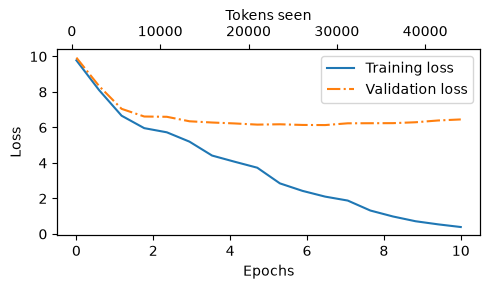

In [64]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # only show integer labels on x-axis

    # Create a second x-axis for tokens seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(tokens_seen, train_losses, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig("loss-plot.pdf")
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

Looking at the results above, we can see that the model starts out generating incomprehensible strings of words, whereas towards the end, it's able to produce grammatically more or less correct sentences. However, based on the training and validation set losses, we can see that the model starts overfitting. If we were to check a few passages it writes towards the end, we would find that they are contained in the training set verbatim - it simply memorizes the training data.

In section 5.3, we will cover decoding strategies that can mitigate this memorization by a certain degree. Note that the overfitting here occurs because we have a very, very small training set and a complex model with large number of trainable paramaters (a recipe for overfitting), and we iterate over it so many times.

The LLM training here primarily serves educational purposes; we mainly want to see that the model can learn to produce coherent text. Instead of spending weeks or months on training this model on vast amounts of expensive hardware, we load pretrained weights later in section 5.4.

<figure style="text-align: center; width: 750px; margin: 0 auto;">
    <img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/13.webp" width=100%>
    <figcaption style="text-align: left; margin-top: 8px;">
        <strong>Figure 5.13</strong> Our model can generate coherent text after implementing the training function. However, it often memorizes passages from the training set verbatim. Next, we will discuss strategies to generate more diverse output texts.
    </figcaption>
</figure>

#### **Bonus materials**

* If you are interested in augmenting this training function with more advanced techniques, such as learning rate warmup, cosine annealing, and gradient 
clipping, please refer to [Appendix D](../../appendix-D/01_main-chapter-code/).

* If you are interested in a larger training dataset and longer training run, see [bonus_pretraining_on_gutenberg](../../../src/llms_from_scratch/ch05/bonus_pretraining_on_gutenberg).

---

## **5.3 Decoding strategies to control randomness**

This section transitions from basic model training to more sophisticated methods for text generation.

The key conceptual and technical points include:

* **Beyond Greedy Decoding**: Previously, the model used "greedy decoding," which always selects the token with the highest probability. This section aims to move beyond that to generate more original and diverse text.
* **Addressing Determinism**: Under greedy decoding, an LLM will always produce the same output for a given starting context. The new strategies introduce a probabilistic selection process to ensure the model doesn't always take the most predictable path.
* **Techniques Introduced**: The source outlines two primary methods to enhance variety and reduce training data memorization:
    1. **Temperature Scaling**: Adjusting the confidence of the probability distribution.
    2. **Top-k Sampling**: Restricting the model's choices to the most likely candidates to maintain grammatical coherence.
* **Preparation for Inference**: Before applying these strategies, the model is transferred to the CPU because inference is relatively cheap with a relatively small LLM as the GPT model we trained above. Also, the model is placed in `.eval()` mode to disable random components like dropout that are strictly for training.

Ultimately, this section provides the tools necessary to transform the LLM from a simple text-completion engine into a more creative and versatile generator.

In [65]:
# NEW: use CPU here as inference is cheap with 
# this model and to ensure readers get same results in the
# remaining sections of this book
inference_device = torch.device("cpu")

model.to(inference_device)
model.eval()

tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(inference_device),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you know," was one of the axioms he laid down across the Sevres and silver of an exquisitely appointed lun


Even if we execute the `generate_text_simple` function above multiple times, the LLM will always generate the same outputs. As mentioned above, we now introduce two concepts, so-called decoding strategies, to modify the `generate_text_simple`: *temperature scaling* and *top-k* sampling. These will allow the model to control the randomness and diversity of the generated text.

### **5.3.1 Temperature scaling**

This sub-section introduces a technique to move beyond greedy decoding by adding a probabilistic selection process to next-token generation.

The key concepts and functional impacts include:

* **Probabilistic Sampling**: Instead of always selecting the token with the highest probability using `torch.argmax`, this strategy uses `torch.multinomial` function to sample the next token proportional to its probability score.
* **The Mechanism**: Temperature scaling is implemented by dividing the logits by a positive number (the temperature, $T$) before they are passed to the softmax function.
* **Controlling Randomness**:
    * **$T > 1$**: Produces a more uniform distribution, making less likely tokens more probable and increasing the variety and creativity of the text.
    *   **$T < 1$**: Creates a sharper, more peaky distribution, increasing the model's confidence in the most likely token and approaching the deterministic behavior of greedy decoding.
    *   **$T = 1$**: Represents the original, unscaled probability distribution.
*   **Trade-offs**: While higher temperatures prevent the model from repeating memorized training data, they also increase the risk of generating grammatically incorrect or nonsensical outputs.

Ultimately, temperature scaling serves as a vital tool for balancing coherence/predictability and creativity, allowing users to tune the LLM's output based on the specific requirements of a task.


> **Side Note**: The choice of the word "temperature" reflects its functional analogy to thermodynamics properties. Much like cooling a physical system reduces its entropy (randomness), setting T below 1 creates a sharper, more "peaky" distribution. This increases the model's confidence in the most likely token, making its output more predictable, coherent, and deterministic. Conversly, increasing the temperature is analogous to adding "heat" or randomness to a system. It results in a more uniform probability distribution, where less likely tokens become more probable. This encourages variety and creative paths in text generation but also increases the risk of generating grammatically incorrect or nonsensical text

Here's a little recap of generating the next token, assuming a very small vocabulary for illustration purposes:

In [66]:
vocab = { 
    "closer": 0,
    "every": 1, 
    "effort": 2, 
    "forward": 3,
    "inches": 4,
    "moves": 5, 
    "pizza": 6,
    "toward": 7,
    "you": 8,
} 

inverse_vocab = {v: k for k, v in vocab.items()}

# Suppose input is "every effort moves you", and the LLM
# returns the following logits for the next token:
next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

probas = torch.softmax(next_token_logits, dim=0)
next_token_id = torch.argmax(probas).item()

# The next generated token is then as follows:
print(inverse_vocab[next_token_id])

forward


In [67]:
torch.manual_seed(123)
next_token_id = torch.multinomial(probas, num_samples=1).item()
print(inverse_vocab[next_token_id])

forward


Instead of determining the most likely token via `torch.argmax`, we use `torch.multinomial(probas, num_samples=1)` to determine the most likely token by sampling from the softmax distribution. For illustration purposes, let's see what happens when we sample the next token 1,000 times using the original softmax probabilities:

In [68]:
def print_sampled_tokens(probas):
    torch.manual_seed(123) # Manual seed for reproducibility
    sample = [torch.multinomial(probas, num_samples=1).item() for i in range(1_000)]
    sampled_ids = torch.bincount(torch.tensor(sample), minlength=len(probas))
    for i, freq in enumerate(sampled_ids):
        print(f"{freq} x {inverse_vocab[i]}")

print_sampled_tokens(probas)

73 x closer
0 x every
0 x effort
582 x forward
2 x inches
0 x moves
0 x pizza
343 x toward
0 x you


We can control the distribution and selection process via temperature scaling:

In [69]:
def softmax_with_temperature(logits, temperature):
    scaled_logits = logits / temperature
    return torch.softmax(scaled_logits, dim=0)

# Temperature values
temperatures = [1, 0.1, 5]  # Original, higher confidence, and lower confidence

# Calculate scaled probabilities
scaled_probas = [softmax_with_temperature(next_token_logits, T) for T in temperatures]

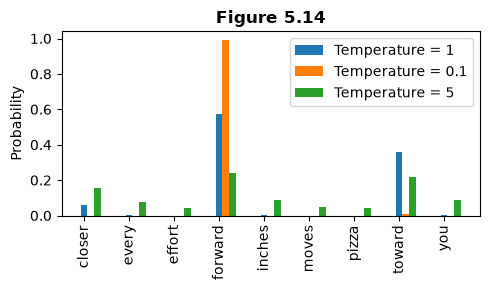

In [70]:
# Plotting
x = torch.arange(len(vocab))
bar_width = 0.15

fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):
    rects = ax.bar(x + i * bar_width, scaled_probas[i], width=bar_width, label=f'Temperature = {T}')

ax.set_title("Figure 5.14", weight="bold")
ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()

plt.tight_layout()
plt.savefig("temperature-plot.pdf")
plt.show()

We can see that the rescaling via temperature 0.1 results in a sharper distribution, approaching `torch.argmax`, such that the most likely word is almost always selected:

In [71]:
print_sampled_tokens(scaled_probas[1])

0 x closer
0 x every
0 x effort
985 x forward
0 x inches
0 x moves
0 x pizza
15 x toward
0 x you


The rescaled probabilities via temperature 5 are more uniformly distributed:

In [72]:
print_sampled_tokens(scaled_probas[2])

165 x closer
75 x every
42 x effort
239 x forward
71 x inches
46 x moves
32 x pizza
227 x toward
103 x you


Assuming an LLM input "every effort moves you", using the approach above can sometimes result in nonsensical texts, such as "every effort moves you pizza", 3.2% of the time (32 out of 1000 times).

#### **Exercise 5.1** 

Use the print_sampled_tokens function to print the sampling frequencies of the softmax probabilities scaled with the temperatures shown in figure 5.14. How often
is the word `pizza` sampled in each case? Can you think of a faster and more accurate way to determine how often the word `pizza` is sampled?

#### **Solution 5.1**

In [73]:
temp_idx = 2
pizza_idx = 6

print(round(scaled_probas[temp_idx][pizza_idx].item()*100,2), "%")

4.3 %


### **5.3.2 Top-k sampling**

This section introduces a refinement to probabilistic decoding that improves text quality by focusing the model's selection on the most likely candidates.

The key conceptual and technical aspects include:

* **Refining Randomness**: While temperature scaling allows for variety, high temperatures can lead to grammatically incorrect or nonsensical outputs (e.g., the model choosing "pizza" in an inappropriate context). Top-k sampling mitigates this by restricting the selection pool.
* **The Masking Mechanism**: In this approach, the model identifies the top $k$ tokens with the highest logit values. All other tokens in the vocabulary are masked with negative infinity (-inf).
* **Probability Redistribution**: When the softmax function is applied to these masked logits, the non-top-k tokens are assigned a probability of zero, while the remaining top $k$ probabilities are rescaled to sum to one. 
* **Balancing Coherence and Creativity**: By excluding the "long tail" of highly improbable tokens, the model is forced to choose from a subset of likely words. This maintains grammatical coherence while still allowing for creative variation among the top candidates when combined with temperature scaling and multinomial sampling.

Ultimately, top-k sampling acts as a safety filter, preventing the model from wandering into nonsensical paths while still permitting more original text than standard greedy decoding.

<figure style="text-align: center; width: 750px; margin: 0 auto;">
    <img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/15.webp" width=100%>
    <figcaption style="text-align: left; margin-top: 8px;">
        <strong>Figure 5.15</strong> Using top-k sampling with k = 3, we focus on the three tokens associated with the highest logits and mask out all other tokens with negative infinity (–inf) before applying the softmax function. This results in a probability distribution with a probability value 0 assigned to all non-top-k tokens. (The numbers in this figure are truncated to two digits after the decimal point to reduce visual clutter. The values in the “Softmax” row should add up to 1.0.)
    </figcaption>
</figure>

In code, we can implement this as follows:

In [74]:
top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k)

print("Top logits:", top_logits)
print("Top positions:", top_pos)

Top logits: tensor([6.7500, 6.2800, 4.5100])
Top positions: tensor([3, 7, 0])


In [75]:
new_logits = torch.where(
    condition=next_token_logits < top_logits[-1],
    input=torch.tensor(float("-inf")), 
    other=next_token_logits
)

print(new_logits)

tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])


An alternative, slightly more efficient implementation of the previous code cell is the following:

```python
new_logits = torch.full_like( # create tensor containing -inf values
   next_token_logits, -torch.inf
)   
new_logits[top_pos] = next_token_logits[top_pos] # copy top k values into the -inf tensor

```

For more details, see https://github.com/rasbt/LLMs-from-scratch/discussions/326

In [76]:
topk_probas = torch.softmax(new_logits, dim=0)
print(topk_probas)

tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


### **5.3.3 Modifying the text generation function**

The previous two subsections introduced temperature sampling and top-k sampling. Let's use these two concepts to modify the `generate_text_simple` function from chapter 4, creating a new `generate` function:

In [77]:
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):

    # For-loop is the same as before: Get logits, and only focus on last time step
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]

        # New: Filter logits with top_k sampling
        if top_k is not None:
            # Keep only top_k values
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(logits < min_val, torch.tensor(float("-inf")).to(logits.device), logits)

        # New: Apply temperature scaling
        if temperature > 0.0:
            logits = logits / temperature

            # New (not in book): numerical stability tip to get equivalent results on mps device
            # subtract rowwise max before softmax
            logits = logits - logits.max(dim=-1, keepdim=True).values
            
            # Apply softmax to get probabilities
            probs = torch.softmax(logits, dim=-1)  # (batch_size, context_len)

            # Sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1)  # (batch_size, 1)

        # Otherwise same as before: get idx of the vocab entry with the highest logits value
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)  # (batch_size, 1)

        if idx_next == eos_id:  # Stop generating early if end-of-sequence token is encountered and eos_id is specified
            break

        # Same as before: append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch_size, num_tokens+1)

    return idx

In [78]:
torch.manual_seed(123)

token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(inference_device),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=25,
    temperature=1.4
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you stand to work on surprise, a one of us had gone with random-


#### **Exercise 5.2**

Play around with different temperatures and top-k settings. Based on your observations, can you think of applications where lower temperature and top-k settings are desired? Likewise, can you think of applications where higher temperature and top-k settings are preferred? (It’s recommended to also revisit this exercise at the end of the chapter after loading the pretrained weights from OpenAI.)

#### **Solution 5.2**

Lower temperature and top-k values are desired for tasks that need more determistic output such as coding, technical writitng. On the other hand, higher values are desired for tasks that are allowed with higher level of randomness such as generating poems, creative writing, or creating new ideas.

#### **Excercise 5.3**

What are the different combinations of settings for the `generate` function to force deterministic behavior, that is, disabling the random sampling such that it always produces the same outputs similar to the `generate_simple` function?

#### **Solution 5.3**

Setting `temperature=0.0` and `top_k=1` will generate the same results everytime the function is called.

---

## **5.4 Loading and saving model weights in PyTorch**

This section addresses the practical necessity of preserving an LLM's progress, given that pretraining is computationally expensive and time-consuming.

Key technical aspects include:

* **The `state_dict` Mechanism**: The recommended method for saving a model involves extracting its `state_dict`, which is a dictionary mapping each layer to its trainable parameters.
* **Saving and Loading**: 
    * **Saving**: Parameters are saved to disk (typically with a `.pth` extension) using `torch.save(model.state_dict(), "model.pth")`.
    * **Loading**: Weights are restored into a new model instance of the same architecture using `model.load_state_dict(torch.load("model.pth"))`.
* **Managing Inference Mode**: Upon loading a model for text generation, it must be placed in `.eval()` mode to disable training-specific components like dropout that would otherwise introduce undesired randomness or interfere with learned weights.
* **Resuming Training**: For scenarios where training needs to be paused and resumed, the source recommends saving the optimizer state alongside the model weights. This is critical for adaptive optimizers like AdamW, which store historical gradient data necessary for proper convergence; without this state, the optimizer would reset, potentially leading to suboptimal learning or training failure.
* **Checkpointing**: A complete checkpoint is created by saving a single dictionary containing both the model and optimizer state dicts, allowing the entire training environment to be restored via `load_state_dict` for both components.

Ultimately, these functions provide a standardized workflow for managing model persistence, enabling researchers to share trained weights or iteratively refine models over multiple sessions.

<figure style="text-align: center; width: 750px; margin: 0 auto;">
    <img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/16.webp" width=100%>
    <figcaption style="text-align: left; margin-top: 8px;">
        <strong>Figure 5.16</strong> After training and inspecting the model, it is often helpful to save the model so that we can use or continue training it later (step 6).
    </figcaption>
</figure>

The recommended way in PyTorch is to save the model weights, the so-called `state_dict` via by applying the `torch.save` function to the `.state_dict()` method:

In [79]:
torch.save(model.state_dict(), "model.pth")

Then we can load the model weights into a new `GPTModel` model instance as follows:

In [80]:
model = GPTModel(GPT_CONFIG_124M)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    # Use PyTorch 2.9 or newer for stable mps results
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Device:", device)

model.load_state_dict(torch.load("model.pth", map_location=device, weights_only=True))
model.eval();

Device: cpu


It's common to train LLMs with adaptive optimizers like Adam or AdamW instead of regular SGD. These adaptive optimizers store additional parameters for each model weight, so it makes sense to save them as well in case we plan to continue the pretraining later:

In [81]:
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    }, 
    "model_and_optimizer.pth"
)

In [82]:
checkpoint = torch.load("model_and_optimizer.pth", weights_only=True)

model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(checkpoint["model_state_dict"])

optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005, weight_decay=0.1)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
model.train();

#### **Exercise 5.4**
After saving the weights, load the model and optimizer in a new Python session or Jupyter notebook file and continue pretraining it for one more epoch using the
train_model_simple function.

#### **Solution 5.4**

In [83]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint = torch.load("./model_and_optimizer.pth", weights_only=True)

model_ = GPTModel(GPT_CONFIG_124M)
model_.load_state_dict(checkpoint['model_state_dict'])

optimizer_ = torch.optim.AdamW(model_.parameters(), lr=0.0005, weight_decay=0.1)
optimizer_.load_state_dict(checkpoint['optimizer_state_dict'])
model_.train()


num_epochs = 1
train_losses_, val_losses_, tokens_seen_= train_model_simple(
    model_, train_loader, val_loader, optimizer_, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)

Ep 1 (Step 000000): Train loss 0.264, Val loss 6.544
Ep 1 (Step 000005): Train loss 0.196, Val loss 6.572
Every effort moves you?"  "Yes--quite insensible to the irony. She wanted him vindicated--and by me!"  He laughed again, and threw back his head to look up at the sketch of the donkey. "There were days when I


---

## **5.5 Loading pretrained weights from OpenAI**

This section details the process of integrating OpenAI's publicly shared GPT-2 weights into the custom model architecture to skip the costly pretraining phase.

Key technical aspects include:

* **Accessing OpenAI Weights**: Because OpenAI originally saved GPT-2 weights using TensorFlow, users must install `tensorflow` and `tqdm` to facilitate the download and loading process via a provided utility script.
* **Architectural Compatibility**: GPT-2 models (ranging from 124M to 1.5B parameters) share the same core architecture. To use these weights, the local model configuration must be updated to match OpenAI’s training settings, specifically increasing the context length to 1,024 tokens and enabling bias vectors (`qkv_bias=True`) in the attention layers.
* **The Weight Mapping Process**: A custom `load_weights_into_gpt` function is implemented to map parameters from OpenAI’s dictionary into the PyTorch `GPTModel`. This involves splitting concatenated attention weights (query, key, and value matrices) and transposing linear layer weights to ensure compatibility with PyTorch’s format.
* **Weight Tying**: Consistent with the original GPT-2, the implementation reuses the token embedding weights in the output head, which significantly reduces the total number of trainable parameters.
* **Validation**: Upon successful loading, the model transitions from generating random gibberish to producing coherent, human-like text, confirming that the parameters were mapped correctly.

Ultimately, this section transforms the model from a basic architectural template into a powerful foundation model ready for downstream fine-tuning tasks like text classification or instruction following.

Our custom `load_weigths_into_gpt` function can be imported from [`gpt_download.py`](../../../src/llms_from_scratch/ch05/main_chapter_code/gpt_download.py) module.


**Note**: Some users may encounter issues in this section due to TensorFlow compatibility problems, particularly on certain Windows systems. TensorFlow is required here only to load the original OpenAI GPT-2 weight files, which we then convert to PyTorch. If you're running into TensorFlow-related issues, you can use the alternative code below instead of the remaining code in this section. This alternative is based on pre-converted PyTorch weights, created using the same conversion process described in the previous section. For details, refer to the notebooks in [02_alternative_weight_loading](../02_alternative_weight_loading/).

First, some boilerplate code to download the files from OpenAI and load the weights into Python. Since OpenAI used [TensorFlow](https://www.tensorflow.org/), we will have to install and use TensorFlow for loading the weights; [tqdm](https://github.com/tqdm/tqdm) is a progress bar library.

Both packages are already installed in our local pixi environment.

In [84]:
print("TensorFlow version:", version("tensorflow"))
print("tqdm version:", version("tqdm"))

TensorFlow version: 2.21.0
tqdm version: 4.68.3


In [94]:
# Relative import from the gpt_download.py contained in this folder
from llms_from_scratch.ch05.main_chapter_code.gpt_download import download_and_load_gpt2

We can then download the model weights for the 124 million parameter model as follows:

In [95]:
settings, params = download_and_load_gpt2(model_size="124M", models_dir="gpt2")

File already exists and is up-to-date: gpt2/124M/checkpoint
File already exists and is up-to-date: gpt2/124M/encoder.json
File already exists and is up-to-date: gpt2/124M/hparams.json
File already exists and is up-to-date: gpt2/124M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/124M/model.ckpt.index
File already exists and is up-to-date: gpt2/124M/model.ckpt.meta
File already exists and is up-to-date: gpt2/124M/vocab.bpe


In [96]:
print("Settings:", settings)

Settings: {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}


In [98]:
print("Parameter dictionary keys:", params.keys())

Parameter dictionary keys: dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])


In [89]:
print(params["wte"])
print("Token embedding weight tensor dimensions:", params["wte"].shape)

[[-0.11010301 -0.03926672  0.03310751 ... -0.1363697   0.01506208
   0.04531523]
 [ 0.04034033 -0.04861503  0.04624869 ...  0.08605453  0.00253983
   0.04318958]
 [-0.12746179  0.04793796  0.18410145 ...  0.08991534 -0.12972379
  -0.08785918]
 ...
 [-0.04453601 -0.05483596  0.01225674 ...  0.10435229  0.09783269
  -0.06952604]
 [ 0.1860082   0.01665728  0.04611587 ... -0.09625227  0.07847701
  -0.02245961]
 [ 0.05135201 -0.02768905  0.0499369  ...  0.00704835  0.15519823
   0.12067825]]
Token embedding weight tensor dimensions: (50257, 768)


Alternatively, "355M", "774M", and "1558M" are also supported `model_size` arguments. The difference between these differently sized models is summarized in the figure below:

<figure style="text-align: center; width: 750px; margin: 0 auto;">
    <img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/17.webp" width=100%>
    <figcaption style="text-align: left; margin-top: 8px;">
        <strong>Figure 5.17</strong> GPT-2 LLMs come in several different model sizes, ranging from 124 million to 1,558 million parameters. The core architecture is the same, with the only difference being the embedding sizes and the number of times individual components like the attention heads and transformer blocks are repeated.
    </figcaption>
</figure>

- Above, we loaded the 124M GPT-2 model weights into Python, however we still need to transfer them into our `GPTModel` instance
- First, we initialize a new GPTModel instance
- Note that the original GPT model initialized the linear layers for the query, key, and value matrices in the multi-head attention module with bias vectors, which is not required or recommended; however, to be able to load the weights correctly, we have to enable these too by setting `qkv_bias` to `True` in our implementation, too
- We are also using the `1024` token context length that was used by the original GPT-2 model(s)

In [100]:
# Define model configurations in a dictionary for compactness
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

# Copy the base configuration and update with specific model settings
model_name = "gpt2-small (124M)"  # Example model name
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])
NEW_CONFIG.update({"context_length": 1024, "qkv_bias": True})

gpt = GPTModel(NEW_CONFIG)
gpt.eval();

The next task is to assign the OpenAI weights to the corresponding weight tensors in our `GPTModel` instance:

In [101]:
def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch. Left: {left.shape}, Right: {right.shape}")
    return torch.nn.Parameter(torch.tensor(right))

In [102]:
print(gpt)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [103]:
print("Parameter dictionary keys:", params.keys())

Parameter dictionary keys: dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])


In [111]:
import numpy as np

def load_weights_into_gpt(gpt, params):
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])
    
    for b in range(len(params["blocks"])):
        q_w, k_w, v_w = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.weight = assign(
            gpt.trf_blocks[b].att.W_query.weight, q_w.T)
        gpt.trf_blocks[b].att.W_key.weight = assign(
            gpt.trf_blocks[b].att.W_key.weight, k_w.T)
        gpt.trf_blocks[b].att.W_value.weight = assign(
            gpt.trf_blocks[b].att.W_value.weight, v_w.T)

        q_b, k_b, v_b = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.bias = assign(
            gpt.trf_blocks[b].att.W_query.bias, q_b)
        gpt.trf_blocks[b].att.W_key.bias = assign(
            gpt.trf_blocks[b].att.W_key.bias, k_b)
        gpt.trf_blocks[b].att.W_value.bias = assign(
            gpt.trf_blocks[b].att.W_value.bias, v_b)

        gpt.trf_blocks[b].att.out_proj.weight = assign(
            gpt.trf_blocks[b].att.out_proj.weight, 
            params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].att.out_proj.bias = assign(
            gpt.trf_blocks[b].att.out_proj.bias, 
            params["blocks"][b]["attn"]["c_proj"]["b"])

        gpt.trf_blocks[b].ff.layers[0].weight = assign(
            gpt.trf_blocks[b].ff.layers[0].weight, 
            params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias, 
            params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.trf_blocks[b].ff.layers[2].weight = assign(
            gpt.trf_blocks[b].ff.layers[2].weight, 
            params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias, 
            params["blocks"][b]["mlp"]["c_proj"]["b"])

        gpt.trf_blocks[b].norm1.scale = assign(
            gpt.trf_blocks[b].norm1.scale, 
            params["blocks"][b]["ln_1"]["g"])
        gpt.trf_blocks[b].norm1.shift = assign(
            gpt.trf_blocks[b].norm1.shift, 
            params["blocks"][b]["ln_1"]["b"])
        gpt.trf_blocks[b].norm2.scale = assign(
            gpt.trf_blocks[b].norm2.scale, 
            params["blocks"][b]["ln_2"]["g"])
        gpt.trf_blocks[b].norm2.shift = assign(
            gpt.trf_blocks[b].norm2.shift, 
            params["blocks"][b]["ln_2"]["b"])

    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])
    
    
load_weights_into_gpt(gpt, params)
gpt.to(device);

If the model is loaded correctly, we can use it to generate new text using our previous `generate` function:

In [118]:
torch.manual_seed(123)

token_ids = generate(
    model=gpt,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=25,
    context_size=NEW_CONFIG["context_length"],
    top_k=50,
    temperature=1.5
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you toward finding an ideal new way to practice something!

What makes us want to be on top of that?




We know that we loaded the model weights correctly because the model can generate coherent text; if we made even a small mistake, the model would not be able to do that.

For an alternative way to load the weights from the Hugging Face Hub, see [02_alternative_weight_loading](../02_alternative_weight_loading).

If you are interested in seeing how the GPT architecture compares to the Llama architecture (a popular LLM developed by Meta AI), see the bonus content at [07_gpt_to_llama](../07_gpt_to_llama).

---

&nbsp;
## Summary and takeaways

- See the [./gpt_train.py](./gpt_train.py) script, a self-contained script for training
- The [./gpt_generate.py](./gpt_generate.py) script loads pretrained weights from OpenAI and generates text based on a prompt
- You can find the exercise solutions in [./exercise-solutions.ipynb](./exercise-solutions.ipynb)